In [1]:
%load_ext autoreload
%autoreload 2

import util as yu
from util import *
import util_moments as yum

projs=['P0', 'Px', 'Py', 'Pz']
inserts=['tt', 'tx', 'ty', 'tz', 'xx', 'xy', 'xz', 'yy', 'yz', 'zz']
enss=['b','c','d','e']

In [2]:
pathlabel='analysis_avgx_2'

tftc2key2bare=yu.load_pkl_reg('tftc2key2bare',pathlabel=pathlabel)
ens2Njk={ens:tftc2key2bare[list(tftc2key2bare.keys())[0]][(ens,'j+;conn')].shape[0] for ens in enss}

key2bare=yu.load_pkl_reg('key2bare_A20_selected',pathlabel=pathlabel)
yum.extendBare_avgx(key2bare)

# RCs
path='data_aux/RCs.pkl'
with open(path,'rb') as f:
    ens2RCs_me=pickle.load(f)
ens2RCs={ens:{} for ens in enss}
for ens in enss:
    for key in ens2RCs_me[ens]:
        if key.endswith('err'):
            continue
        ens2RCs[ens][key]=yu.jackknife_pseudo(ens2RCs_me[ens][key],ens2RCs_me[ens][f'{key}_err']*0+1e-10,ens2Njk[ens])[:,0]
        
path='data_aux/RCs_pre.pkl'
with open(path,'rb') as f:
    ens2RCs_pre_me=pickle.load(f)
ens2RCs_pre={ens:{} for ens in ens2RCs_pre_me.keys()}
for ens in ens2RCs_pre_me.keys():
    for key in ens2RCs_pre_me[ens]:
        if key.endswith('err'):
            continue
        ens2RCs_pre[ens][key]=yu.jackknife_pseudo(ens2RCs_pre_me[ens][key],ens2RCs_pre_me[ens][f'{key}_err']*0+1e-10,ens2Njk[ens])[:,0]
        
key2phy=yum.bareRC2phy_avgx(key2bare,ens2RCs)

In [3]:
PDF_SET='NNPDF40_nnlo_as_01180'
PDF_SET='JAM22-PDF_proton_nlo'

j2me=yu.load_pkl(f'pkl/lhapdf/reg_ignore/j2me_{PDF_SET}.pkl')
j2color={'jq':'purple','jg':'cyan','jtot':'grey','ju':'r','jd':'g','js':'b','jc':'orange'}
j2label={'jq':'q','jg':'g','jtot':'N','ju':'u','jd':'d','js':'s','jc':'c'}
j2fmt={'jq':'d','jg':'s','jtot':'o','ju':'^','jd':'v','js':'<','jc':'>'}

def addexp(ax0,ax1):
    ax=ax0
    for j in ['jtot','jq','jg']:
        m,e=j2me[j]
        ax.errorbar(0.0002,m,e,color=j2color[j],mfc='white',fmt=j2fmt[j],markersize=4)
    ax=ax1
    for j in ['ju','jd','js','jc']:
        m,e=j2me[j]
        ax.errorbar(0.0002,m,e,color=j2color[j],mfc='white',fmt=j2fmt[j],markersize=4)

def addexp_span(ax0,ax1):
    ax=ax0
    for j in ['jtot','jq','jg']:
        m,e=j2me[j]
        ax.axhspan(m-e,m+e,color=j2color[j],alpha=0.4)
    ax=ax1
    for j in ['ju','jd','js','jc']:
        m,e=j2me[j]
        ax.axhspan(m-e,m+e,color=j2color[j],alpha=0.4)

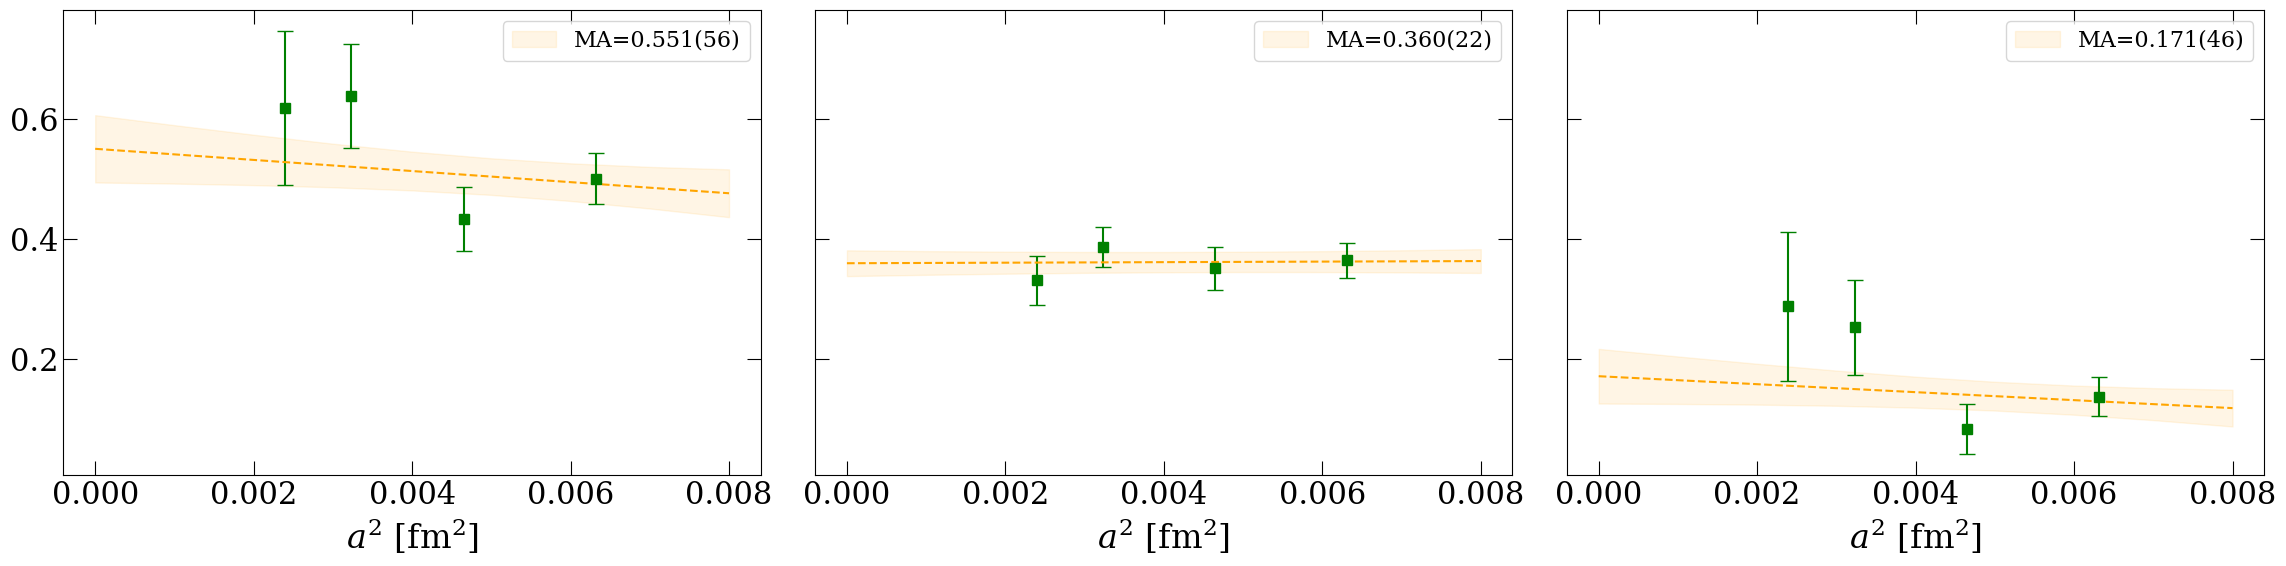

In [4]:
def get(js):
    if not isinstance(js,list):
        js=[js]
    ens2dat={
        ens:np.sum([key2phy[(ens,j)] for j in js],axis=0)
    for ens in enss}

    fits=yu.doFits_continuumExtrapolation(ens2dat,lat_a2s_plt=yum.lat_a2s_plt)
    dic={'ens2dat':ens2dat, 'fit:[fits,lat_a2s_plt]':[fits,yum.lat_a2s_plt]}
    return dic

dic1=get('jq;stout10')
dic2=get('jq;conn;stout10')
dic3=get(['jq;disc;stout10','jq;mix;stout10'])

fig,axs=yu.makePlot_continuumExtrapolation([dic1,dic2,dic3])
ax=axs[0,0]

fits=dic2['fit:[fits,lat_a2s_plt]'][0]
pars_jk2,probs_jk=yu.jackMA(fits)
fits=dic3['fit:[fits,lat_a2s_plt]'][0]
pars_jk3,probs_jk=yu.jackMA(fits)

pars_jk=pars_jk2+pars_jk3

mean,err=yu.jackme(pars_jk)
x=yum.lat_a2s_plt; ymin=mean-err; ymax=mean+err
# ax.plot(x,mean,color='r',linestyle='--',marker='')
# ax.fill_between(x, ymin, ymax, color='r', alpha=0.1,label=f'MA={yu.un2str(mean[0],err[0])}')
# ax.legend()
yu.finalizePlot() 